# alternatives-analysis

Boulder Valley's Resilient Schools proposal recommends closing four
elementary schools. It is presented as a single plan. This notebook asks
three questions the plan does not:

1. **Has this happened before?** Colorado has been closing schools for forty
   years. What predicts a closure, and what happened afterwards?
2. **How many schools does the demography actually support?** Fitted across
   every Colorado district rather than Boulder's own history, and carried to
   2060 with the uncertainty attached.
3. **What are the options?** Closing schools is one lever. There are others,
   and each is judged here on what it is actually trying to do.

**Financials are out of scope by instruction.** Nothing below costs or saves
money. The question is whether there are enough children.

Everything is read from `data/analysis/`, written by
`alternatives-retrieval.ipynb`. No network call is made and no key is read.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)
HERE = Path.cwd()
ANALYSIS = HERE / "data" / "analysis"
OUTPUT = HERE / "output"
OUTPUT.mkdir(exist_ok=True)

BVSD_CODE = "0480"
SVVSD_CODE = "0470"           # St Vrain Valley, the neighbouring district
BOULDER_FIPS = "013"

INK = "#22303f"
ACCENT = "#c1440e"
MUTED = "#8a9aa8"
GRID = "#dfe5ea"
PALETTE = ["#22303f", "#c1440e", "#3d7068", "#b08968", "#6b7a8f", "#8c5e58"]
mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9, "axes.spines.top": False,
    "axes.spines.right": False, "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "text.color": INK,
    "grid.color": GRID, "grid.linewidth": 0.7, "legend.frameon": False,
    "legend.fontsize": 8.5, "font.size": 9.5,
})

def finish(ax, title, subtitle=None, source=None):
    """House style: title above, source below, horizontal grid only."""
    ax.set_title(title, pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
    if source:
        ax.figure.text(0.01, -0.02, source, fontsize=7.5, color=MUTED, ha="left")
    return ax

codes = {"district_code": str, "school_code": str, "ncessch": str, "countyfips": str}
panel = pd.read_csv(ANALYSIS / "district-panel.csv", dtype=codes)
school_panel = pd.read_csv(ANALYSIS / "school-panel.csv", dtype=codes)
registry = pd.read_csv(ANALYSIS / "school-registry.csv", dtype=codes)
bvsd_schools = pd.read_csv(ANALYSIS / "bvsd-schools.csv", dtype=codes)
proposal_actions = pd.read_csv(ANALYSIS / "proposal-actions.csv", dtype=codes)
proposal_figures = pd.read_csv(ANALYSIS / "proposal-figures.csv")
proposal_capacity = pd.read_csv(ANALYSIS / "proposal-capacity.csv", dtype=codes)
says = proposal_figures.set_index("name")["value"]
print(f"district panel   {len(panel):,} rows   {panel['year'].min()}-{panel['year'].max()}"
      f"   {panel['district_code'].nunique()} districts")
print(f"school panel     {len(school_panel):,} rows")
print(f"BVSD schools     {len(bvsd_schools)} in {int(bvsd_schools['year'].iloc[0])}")

district panel   5,989 rows   1990-2024   180 districts
school panel     66,828 rows
BVSD schools     56 in 2024


## 1. Colorado has been closing schools the whole time

The first thing the archive says is that closure is not an event. It is a
rate. Between 1986 and 2024 Colorado schools disappeared from the panel
every single year, in good demographic times and bad — while the number of
schools rose by half.

The labels come from the archive, which assigns them **from the data alone
and never hand-verifies them** (`decision-log.md`, D6). A closure, a merger,
a rename and a code change can look alike. The confidence column travels
with every figure below, and Boulder's own closures are checked one by one
further down, because that is where the argument rests on buildings.

In [2]:
# When is a school "closed"? The archive records the years it is observed and
# a label for its disappearance. Two choices turn that into an event.
#
# **Which disappearances count.** Only those the registry labels `closed` or
# `merged`. A rename or a code change is the same building under another
# name, and the registry's confidence column says how sure it is.
#
# **Which year to measure.** Not the last one. A closing school's final
# observed year is not a normal year of operation - only 39 of the 656
# closing schools have an enrollment recorded in it at all, and the median of
# those is 75 pupils against 391 for every school that year. Measuring a
# school at the moment of its collapse and then finding that small schools
# close is circular.
#
# So the event is **gone within two years**: the school is observed in year t,
# absent from t+2 onward, and labelled closed or merged. Year t is still a
# normal year - 564 of the 656 have an enrollment in it.
panel_end = int(school_panel["year"].max())
sp = school_panel.dropna(subset=["ncessch"]).sort_values(["ncessch", "year"]).copy()
shut = set(sp.loc[sp["closure_label"].isin(["closed", "merged"]), "ncessch"])
last_seen = sp.groupby("ncessch")["year"].max()
# One event per school, in its last normal year. The final observed year is
# dropped from the risk set altogether: a school in the middle of closing is
# neither a school that survived nor a fair measurement of one.
sp["is_final_year"] = sp["year"] == sp["ncessch"].map(last_seen)
sp = sp[~sp["is_final_year"]].copy()
closing_year = {school: year - 1 for school, year in last_seen.items()
                if school in shut and year < panel_end}
sp["gone_in_2"] = [int(closing_year.get(row.ncessch) == row.year)
                   for row in sp.itertuples()]
events = sp[sp["gone_in_2"] == 1]
print(f"{len(sp):,} school-years, {sp['ncessch'].nunique():,} schools")
print(f"closure events (the last normal year of a school that shut): "
      f"{int(sp['gone_in_2'].sum()):,}")
print(f"with an enrollment recorded in the event year: "
      f"{events['enrollment'].notna().sum():,} ({events['enrollment'].notna().mean():.0%})")

63,093 school-years, 2,626 schools
closure events (the last normal year of a school that shut): 638
with an enrollment recorded in the event year: 564 (88%)


### Schools come and go every year

Colorado opened 1,373 schools and closed 725 between 1987 and 2023. Closure
is not an event that happens to a district; it is a rate that every district
lives with.

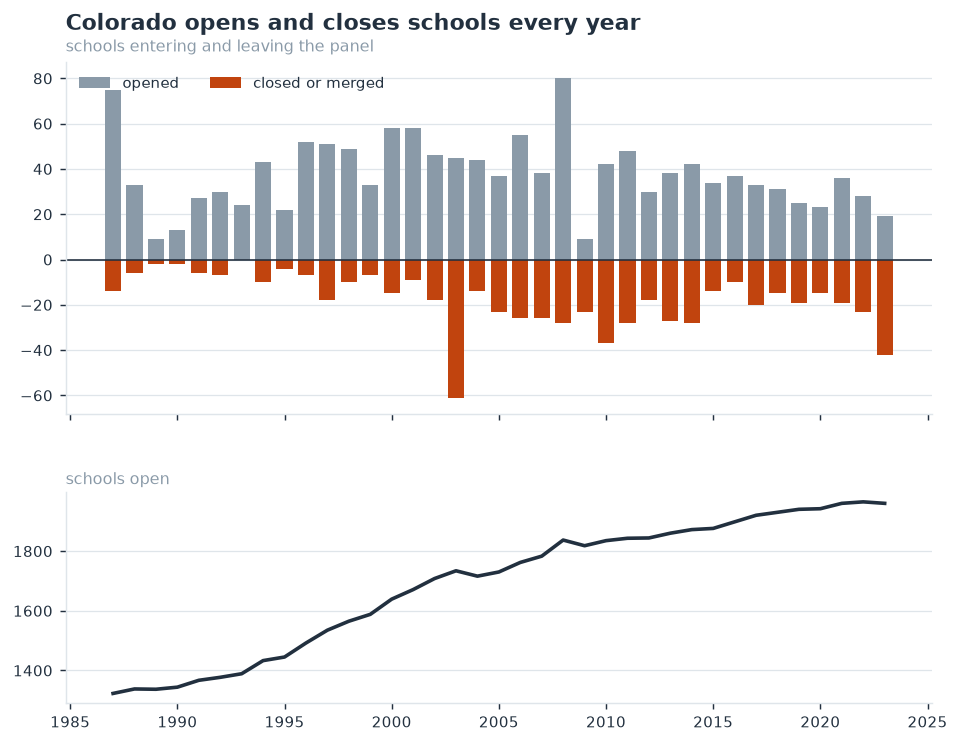

closures 1987-2023: 651   openings: 1,397   net: +746


In [3]:
first_seen = school_panel.dropna(subset=["ncessch"]).groupby("ncessch")["year"].min()
gone = last_seen[last_seen.index.isin(shut) & (last_seen < panel_end)]
per_year = pd.DataFrame({
    "opened": first_seen.value_counts(),
    "closed": gone.value_counts(),
    "open": school_panel.groupby("year")["ncessch"].nunique(),
}).fillna(0).astype(int).sort_index()
per_year = per_year.loc[1987:panel_end - 1]
per_year["net"] = per_year["opened"] - per_year["closed"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.2], "hspace": 0.28})
ax1.bar(per_year.index, per_year["opened"], color=MUTED, label="opened", width=0.75)
ax1.bar(per_year.index, -per_year["closed"], color=ACCENT, label="closed or merged", width=0.75)
ax1.axhline(0, color=INK, lw=0.9)
ax1.legend(loc="upper left", ncols=2)
finish(ax1, "Colorado opens and closes schools every year",
       "schools entering and leaving the panel")
ax2.plot(per_year.index, per_year["open"], color=INK, lw=2)
finish(ax2, "", "schools open")
fig.savefig(OUTPUT / "alt-fig1-openings-closures.png", bbox_inches="tight")
per_year.to_csv(OUTPUT / "alt-fig1-openings-closures.csv")
plt.show()
print(f"closures {per_year.index.min()}-{per_year.index.max()}: {per_year['closed'].sum():,}"
      f"   openings: {per_year['opened'].sum():,}   net: {per_year['net'].sum():+,}")

### A closing school is small years before it closes

The size of a school in each of the five years before it disappears, against
every school in the same year. This is the shape a closure has: not a cliff,
a slope.

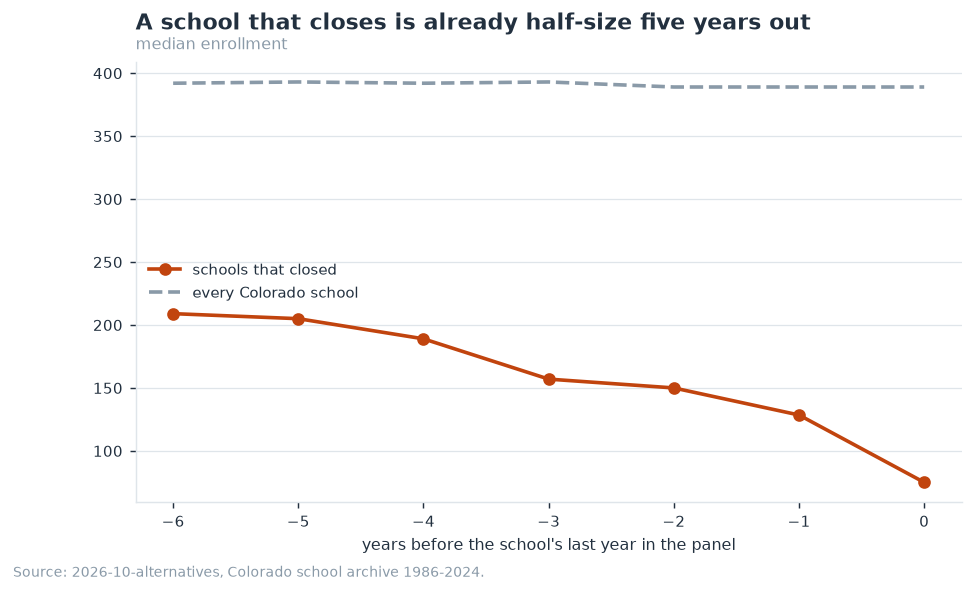

    schools  closing_median  all_median  share_of_typical
t                                                        
-6      410           209.0       392.0              0.53
-5      438           205.0       393.0              0.52
-4      473           189.0       392.0              0.48
-3      511           157.0       393.0              0.40
-2      543           150.0       389.0              0.39
-1      564           128.5       389.0              0.33
 0       39            75.0       389.0              0.19


In [4]:
last_of = gone.rename("last").reset_index()
run_up = school_panel.dropna(subset=["ncessch"]).merge(last_of, on="ncessch")
run_up = run_up[run_up["year"] <= run_up["last"]]
run_up["t"] = run_up["year"] - run_up["last"]
all_median = school_panel.groupby("year")["enrollment"].median().rename("all_median")
run_up = run_up.merge(all_median, on="year")
profile = (run_up[run_up["t"].between(-6, 0)]
           .groupby("t")
           .agg(schools=("enrollment", "count"),
                closing_median=("enrollment", "median"),
                all_median=("all_median", "median")))
profile["share_of_typical"] = profile["closing_median"] / profile["all_median"]

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(profile.index, profile["closing_median"], marker="o", color=ACCENT, lw=2,
        label="schools that closed")
ax.plot(profile.index, profile["all_median"], color=MUTED, lw=2, ls="--",
        label="every Colorado school")
ax.set_xlabel("years before the school's last year in the panel")
ax.legend(loc="center left")
finish(ax, "A school that closes is already half-size five years out",
       "median enrollment",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
fig.savefig(OUTPUT / "alt-fig1b-run-up.png", bbox_inches="tight")
profile.to_csv(OUTPUT / "alt-fig1b-run-up.csv")
plt.show()
print(profile.round(2).to_string())

### What predicts a closure

A logistic model of whether a school is gone within two years, fitted on
every Colorado school-year with an enrollment. The candidates are what a
district actually looks at: how small the school is, whether it is
shrinking, how large its district is and whether the district is shrinking.
Year effects absorb the statewide cycle.

Size is entered as a log, because the difference between 150 pupils and 250
matters far more than between 850 and 950.

In [5]:
model_rows = sp[(sp["enrollment"] > 0) & sp["year"].between(1990, panel_end - 2)].copy()
model_rows = model_rows.sort_values(["ncessch", "year"])
model_rows["log_enrollment"] = np.log(model_rows["enrollment"])
model_rows["enrollment_3yr"] = (model_rows.groupby("ncessch")["enrollment"]
                                .pct_change(3, fill_method=None))
district_size = (model_rows.groupby(["year", "district_code"])["enrollment"]
                 .sum().rename("district_enrollment").reset_index()
                 .sort_values(["district_code", "year"]))
district_size["district_3yr"] = (district_size.groupby("district_code")["district_enrollment"]
                                 .pct_change(3, fill_method=None))
model_rows = model_rows.merge(district_size, on=["year", "district_code"], how="left")
model_rows["log_district"] = np.log(model_rows["district_enrollment"].clip(lower=1))

fit_rows = model_rows.dropna(subset=["log_enrollment", "enrollment_3yr",
                                     "log_district", "district_3yr", "gone_in_2"])
closure_model = smf.logit(
    "gone_in_2 ~ log_enrollment + enrollment_3yr + log_district + district_3yr + C(year)",
    data=fit_rows).fit(disp=False)
terms = ["log_enrollment", "enrollment_3yr", "log_district", "district_3yr"]
summary = pd.DataFrame({
    "coefficient": closure_model.params[terms],
    "std_error": closure_model.bse[terms],
    "p_value": closure_model.pvalues[terms],
    "odds_ratio": np.exp(closure_model.params[terms]),
})
print(f"fitted on {int(closure_model.nobs):,} school-years, "
      f"{int(fit_rows['gone_in_2'].sum()):,} closures"
      f"   pseudo R-squared {closure_model.prsquared:.3f}\n")
print(summary.round(4).to_string())
halving = np.exp(closure_model.params["log_enrollment"] * -np.log(2))
print(f"\nHalve a school's enrollment, hold the year and the district constant,"
      f"\nand it is {halving:.1f} times as likely to be gone within two years.")
summary.to_csv(OUTPUT / "alt-closure-model.csv")

fitted on 47,332 school-years, 435 closures   pseudo R-squared 0.145

                coefficient  std_error  p_value  odds_ratio
log_enrollment      -1.0536     0.0415   0.0000      0.3487
enrollment_3yr      -0.1903     0.1326   0.1513      0.8267
log_district         0.2653     0.0256   0.0000      1.3038
district_3yr        -0.3095     0.3214   0.3355      0.7338

Halve a school's enrollment, hold the year and the district constant,
and it is 2.1 times as likely to be gone within two years.


### The size at which Colorado actually closes a school

Not a rule anyone wrote down — the observed rate. For each enrollment band,
the share of school-years that turned out to be a school's last.

This is the empirical answer to "how small is too small", and it is the
number to hold BVSD's own standard against.

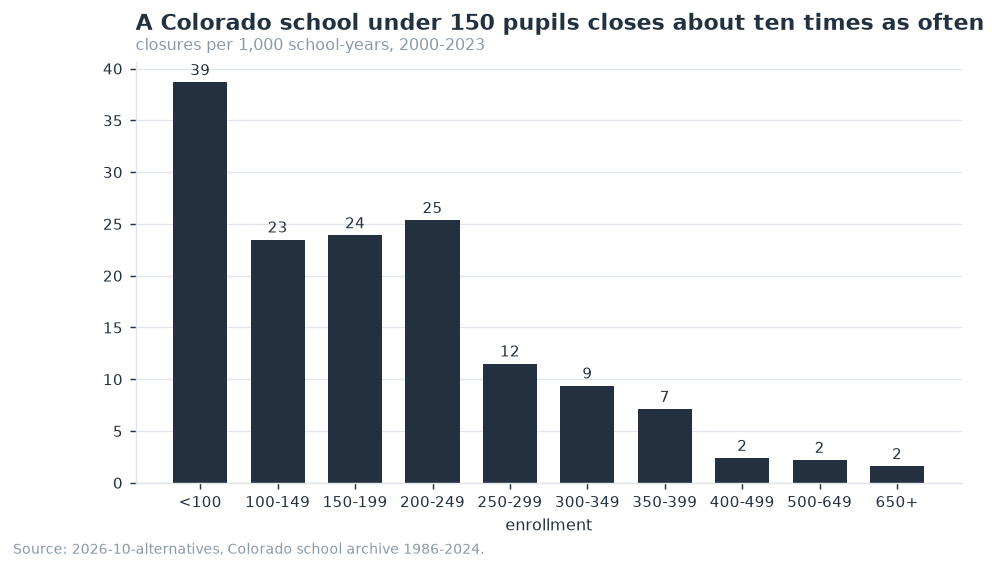

         school_years  closures  annual_rate  per_1000
band                                                  
<100             4784       185      0.03867     38.67
100-149          2641        62      0.02348     23.48
150-199          1884        45      0.02389     23.89
200-249          2406        61      0.02535     25.35
250-299          2782        32      0.01150     11.50
300-349          3308        31      0.00937      9.37
350-399          3233        23      0.00711      7.11
400-499          6293        15      0.00238      2.38
500-649          6377        14      0.00220      2.20
650+             7551        12      0.00159      1.59


In [6]:
bands = [0, 100, 150, 200, 250, 300, 350, 400, 500, 650, 10_000]
labels = ["<100", "100-149", "150-199", "200-249", "250-299", "300-349",
          "350-399", "400-499", "500-649", "650+"]
recent = model_rows[model_rows["year"].between(2000, panel_end - 2)].copy()
recent["band"] = pd.cut(recent["enrollment"], bands, labels=labels, right=False)
hazard = (recent.groupby("band", observed=True)
          .agg(school_years=("gone_in_2", "size"), closures=("gone_in_2", "sum")))
hazard["annual_rate"] = hazard["closures"] / hazard["school_years"]
hazard["per_1000"] = hazard["annual_rate"] * 1000

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(hazard.index.astype(str), hazard["per_1000"], color=INK, width=0.7)
for i, (rate, n) in enumerate(zip(hazard["per_1000"], hazard["school_years"])):
    ax.text(i, rate + 0.7, f"{rate:.0f}", ha="center", fontsize=8.5, color=INK)
finish(ax, "A Colorado school under 150 pupils closes about ten times as often",
       "closures per 1,000 school-years, 2000-2023",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
ax.set_xlabel("enrollment")
fig.savefig(OUTPUT / "alt-fig2-closure-hazard.png", bbox_inches="tight")
hazard.to_csv(OUTPUT / "alt-fig2-closure-hazard.csv")
plt.show()
print(hazard.round({"annual_rate": 5, "per_1000": 2}).to_string())

### Boulder Valley's own record

The archive's auto-labels find almost nothing in Boulder Valley: two
schools, both small special programmes. That is not because nothing
happened. It is because a label assigned from the data alone cannot tell a
closure from a rename, and the archive says so.

So this is done by hand, from the panel: every school that appears in BVSD
and then stops appearing, with the years on either side. What the data can
establish — that a building stopped taking pupils and where those pupils
went — is separated from what it cannot, which is why.

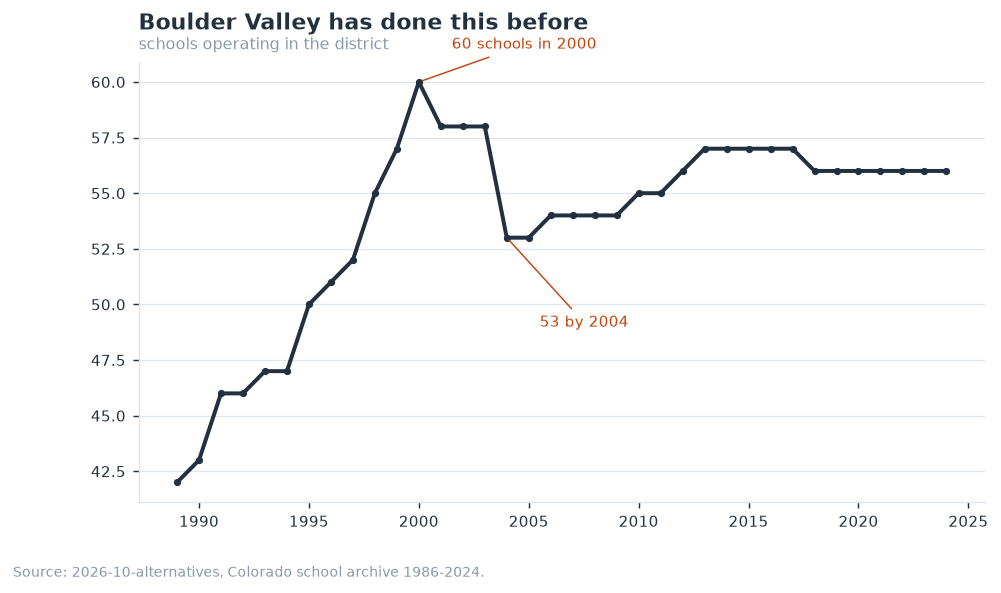

      schools  enrollment  teacher_fte
year                                  
1990       43     21502.0       1141.0
1995       50     25230.0       1328.0
2000       60     27508.0       1572.0
2004       53     27926.0       1656.0
2010       55     29526.0       1682.0
2015       57     31247.0       1639.0
2020       56     29261.0       1690.0
2024       56     27991.0       1583.0


In [7]:
bvsd_panel = sp[sp["district_code"] == BVSD_CODE]
bvsd_by_year = (school_panel[school_panel["district_code"] == BVSD_CODE]
                .groupby("year")
                .agg(schools=("ncessch", "nunique"),
                     enrollment=("enrollment", "sum"),
                     teacher_fte=("teacher_fte", "sum")))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.plot(bvsd_by_year.index, bvsd_by_year["schools"], color=INK, lw=2.2, marker="o", ms=3)
peak = bvsd_by_year["schools"].idxmax()
ax.annotate(f"{int(bvsd_by_year['schools'].max())} schools in {peak}",
            xy=(peak, bvsd_by_year["schools"].max()),
            xytext=(peak + 1.5, bvsd_by_year["schools"].max() + 1.5),
            fontsize=8.5, color=ACCENT,
            arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))
trough = bvsd_by_year.loc[peak:peak + 6, "schools"].idxmin()
ax.annotate(f"{int(bvsd_by_year.loc[trough, 'schools'])} by {trough}",
            xy=(trough, bvsd_by_year.loc[trough, "schools"]),
            xytext=(trough + 1.5, bvsd_by_year.loc[trough, "schools"] - 4),
            fontsize=8.5, color=ACCENT,
            arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))
finish(ax, "Boulder Valley has done this before",
       "schools operating in the district",
       "Source: 2026-10-alternatives, Colorado school archive 1986-2024.")
fig.savefig(OUTPUT / "alt-fig3-bvsd-schools.png", bbox_inches="tight")
bvsd_by_year.to_csv(OUTPUT / "alt-fig3-bvsd-schools.csv")
plt.show()
marks = [y for y in (1986, 1990, 1995, 2000, 2004, 2010, 2015, 2020, 2024)
         if y in bvsd_by_year.index]
print(bvsd_by_year.loc[marks].round(0).to_string())

In [8]:
# Every school that leaves the BVSD panel, with what the data can say.
bv_rows = school_panel[school_panel["district_code"] == BVSD_CODE]
bv_last = bv_rows.groupby("ncessch").agg(
    name=("school_name", "last"), first_year=("year", "min"), last_year=("year", "max"))
elsewhere = (school_panel.groupby("ncessch")["year"].max().rename("last_anywhere"))
bv_last = bv_last.join(elsewhere)
departures = bv_last[bv_last["last_year"] < panel_end].copy()

def enrollment_at(school, year):
    row = bv_rows[(bv_rows["ncessch"] == school) & (bv_rows["year"] == year)]
    return float(row["enrollment"].iloc[0]) if len(row) and pd.notna(row["enrollment"].iloc[0]) else np.nan

departures["enrollment_last"] = [enrollment_at(s, y) for s, y in
                                 zip(departures.index, departures["last_year"])]
departures["enrollment_3_before"] = [enrollment_at(s, y - 3) for s, y in
                                     zip(departures.index, departures["last_year"])]
departures["seen_after_elsewhere"] = departures["last_anywhere"] > departures["last_year"]
departures["what_the_data_shows"] = np.where(
    departures["seen_after_elsewhere"],
    "kept its NCES id outside BVSD - a transfer or a recode, not a closure",
    "leaves the panel entirely")
departures = departures.sort_values("last_year")
print(f"{len(departures)} schools leave the BVSD panel before {panel_end}\n")
print(departures[["name", "first_year", "last_year", "enrollment_3_before",
                  "enrollment_last", "what_the_data_shows"]]
      .to_string(max_colwidth=52))
departures.to_csv(OUTPUT / "alt-bvsd-departures.csv")

10 schools leave the BVSD panel before 2024

                                                name  first_year  last_year  enrollment_3_before  enrollment_last                                  what_the_data_shows
ncessch                                                                                                                                                               
080249000137             VOCATIONAL TECHNICAL CENTER        1989       1995                  NaN              NaN                            leaves the panel entirely
080249000097              AURORA 7 ELEMENTARY SCHOOL        1989       2000                256.0              NaN                            leaves the panel entirely
080249000126            MAJESTIC HEIGHTS ELEM SCHOOL        1989       2000                256.0              NaN                            leaves the panel entirely
080249000098      BASE LINE MIDDLE SCHOOL-ARTS FOCUS        1989       2003                487.0              NaN       

## 2. How many schools does the demography support?

The forecast in `2025-09-enrollments` regressed BVSD enrollment on Boulder
County's school-age population. It fits well, and it has one structural
weakness: it is fitted on **one district's own history**, so it can only
learn what Boulder has already done. If Boulder has never operated at the
staffing level the 2050s imply, the model has never seen it.

The archive makes a different fit possible. **Every Colorado district, every
year** — a panel of 180 districts over three decades, in which districts
have already lived through every demographic path Boulder is heading down.
With district fixed effects the relationship is identified from how
districts respond to *their own* population changing, not from the fact that
large counties have large districts.

Two quantities are fitted: teaching staff, and the number of schools.

In [9]:
model = panel.dropna(subset=["pop_5_17", "teacher_fte", "schools"]).copy()
model = model[(model["teacher_fte"] > 0) & (model["schools"] > 0) & (model["pop_5_17"] > 0)]
model["log_fte"] = np.log(model["teacher_fte"])
model["log_schools"] = np.log(model["schools"])
model["log_pop"] = np.log(model["pop_5_17"])
model["district"] = model["district_code"]
print(f"{len(model):,} district-years, {model['district'].nunique()} districts, "
      f"{model['year'].min()}-{model['year'].max()}")

fits = {}
for label, outcome in [("teacher FTE", "log_fte"), ("schools", "log_schools")]:
    fit = smf.ols(f"{outcome} ~ log_pop + C(district) + year", data=model).fit(
        cov_type="cluster", cov_kwds={"groups": model["district"]})
    fits[label] = fit
    print(f"\n{label}: elasticity to county 5-17 population = "
          f"{fit.params['log_pop']:.3f} "
          f"(95% CI {fit.conf_int().loc['log_pop', 0]:.3f} to "
          f"{fit.conf_int().loc['log_pop', 1]:.3f}), "
          f"within-R² {fit.rsquared:.3f}")
    print(f"   a 10% fall in the school-age population implies a "
          f"{(1.10 ** fit.params['log_pop'] - 1) * -100:.1f}% fall in {label} "
          f"— less than proportional" if fit.params["log_pop"] < 1 else "")

elasticities = pd.DataFrame({
    label: {"elasticity": fit.params["log_pop"],
            "ci_low": fit.conf_int().loc["log_pop", 0],
            "ci_high": fit.conf_int().loc["log_pop", 1],
            "districts": model["district"].nunique(),
            "district_years": int(fit.nobs)}
    for label, fit in fits.items()}).T
elasticities.to_csv(OUTPUT / "alt-elasticities.csv")
print()
print(elasticities.round(3).to_string())

5,301 district-years, 178 districts, 1990-2024



teacher FTE: elasticity to county 5-17 population = 0.750 (95% CI 0.618 to 0.882), within-R² 0.978
   a 10% fall in the school-age population implies a -7.4% fall in teacher FTE — less than proportional

schools: elasticity to county 5-17 population = 0.427 (95% CI 0.287 to 0.567), within-R² 0.963
   a 10% fall in the school-age population implies a -4.2% fall in schools — less than proportional

             elasticity  ci_low  ci_high  districts  district_years
teacher FTE       0.750   0.618    0.882      178.0          5301.0
schools           0.427   0.287    0.567      178.0          5301.0


### Districts shed schools far more slowly than they shed children

Both elasticities are well below 1, and the school elasticity is barely half
the staffing one. A district that loses 10% of its school-age population
ends up with about 7.4% fewer teachers and **4.2% fewer schools**.

This is the single most important number for the Resilient Schools
argument, and it cuts both ways. It means a shrinking district does *not*
need to close schools in proportion to its losses — the observed behaviour
of 178 Colorado districts over thirty-five years says they do not. It also
means the schools that stay get smaller, which is the condition BVSD says it
is trying to escape.

The two facts are the trade-off. Colorado districts have, on the whole,
chosen smaller schools over fewer schools.

### Against the single-district model it replaces

`2025-09-enrollments` fitted BVSD alone. Refitting that here, on the same
data, shows what the panel buys: the single-district fit is steeper and far
less certain, because one district's history contains one path.

In [10]:
bvsd_model = model[model["district_code"] == BVSD_CODE]
comparison = []
for label, outcome in [("teacher FTE", "log_fte"), ("schools", "log_schools")]:
    single = smf.ols(f"{outcome} ~ log_pop + year", data=bvsd_model).fit()
    comparison.append({
        "outcome": label, "fit": "BVSD alone",
        "elasticity": single.params["log_pop"],
        "ci_low": single.conf_int().loc["log_pop", 0],
        "ci_high": single.conf_int().loc["log_pop", 1],
        "observations": int(single.nobs)})
    comparison.append({
        "outcome": label, "fit": "180-district panel",
        "elasticity": fits[label].params["log_pop"],
        "ci_low": fits[label].conf_int().loc["log_pop", 0],
        "ci_high": fits[label].conf_int().loc["log_pop", 1],
        "observations": int(fits[label].nobs)})
comparison = pd.DataFrame(comparison)
comparison["ci_width"] = comparison["ci_high"] - comparison["ci_low"]
print(comparison.round(3).to_string(index=False))
comparison.to_csv(OUTPUT / "alt-model-comparison.csv", index=False)

    outcome                fit  elasticity  ci_low  ci_high  observations  ci_width
teacher FTE         BVSD alone       0.912   0.596    1.229            31     0.632
teacher FTE 180-district panel       0.750   0.618    0.882          5301     0.264
    schools         BVSD alone       0.835   0.585    1.085            31     0.500
    schools 180-district panel       0.427   0.287    0.567          5301     0.280


### Boulder Valley to 2060

The SDO's Vintage 2024 forecast for Boulder County's 5-to-17 population,
put through the panel model, with the district held at its own fitted level.

The shaded band is the 95% interval on **where the relationship puts Boulder
Valley** — the uncertainty in the fitted line, given Boulder's own level.
A second, much wider interval is carried in the output CSV: the spread of
individual districts around the line, which runs from 35 to 79 schools in
2060 and is a statement about how differently districts behave, not about
Boulder.

The demographic path is a single line because the SDO publishes one.
**A reader should treat either band as the least of the uncertainty**, not
the whole of it: neither says anything about whether the SDO's migration
assumptions hold.

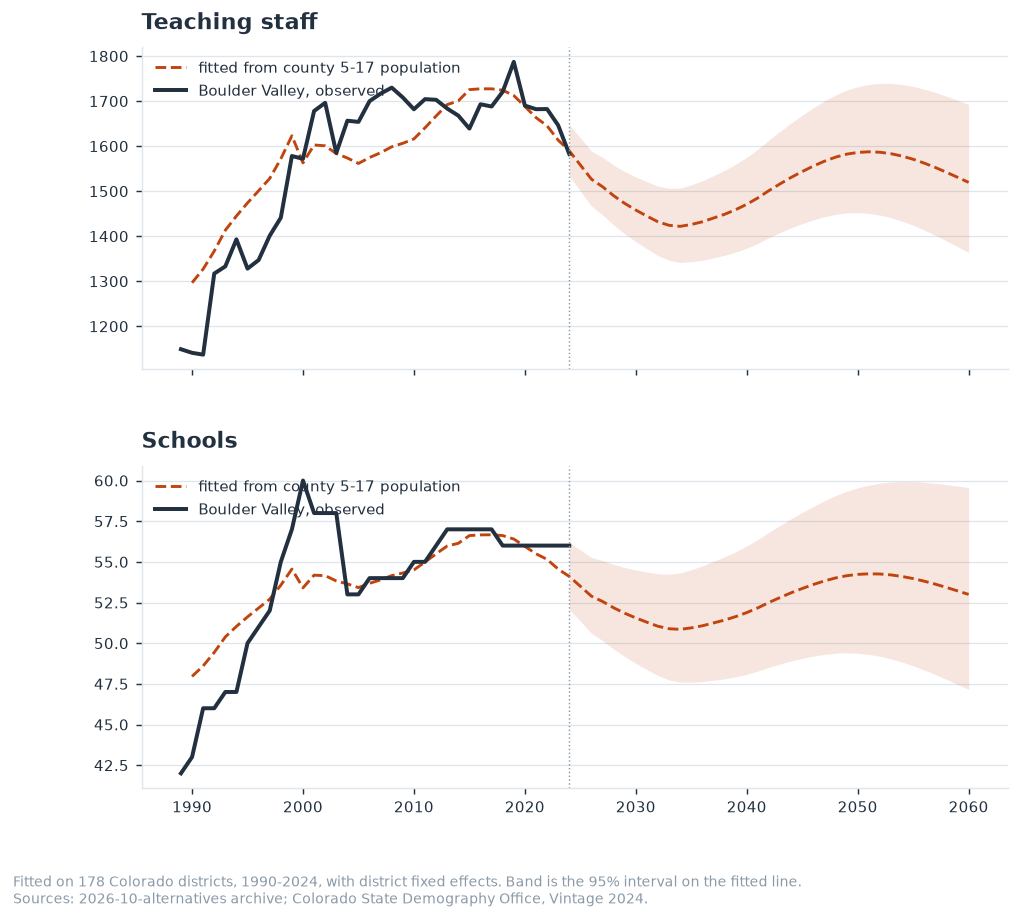

      pop_5_17  teacher_fte  teacher_fte_low  teacher_fte_high  schools  schools_low  schools_high
year                                                                                              
2024     43997       1590.0           1533.0            1648.0     54.0         52.0          56.0
2030     38685       1458.0           1388.0            1532.0     52.0         49.0          55.0
2040     38270       1471.0           1373.0            1575.0     52.0         48.0          56.0
2050     41372       1586.0           1452.0            1732.0     54.0         49.0          60.0
2060     38207       1519.0           1364.0            1693.0     53.0         47.0          60.0

Boulder Valley today (2024): 56 schools, 1,583 teacher FTE
Fitted for 2060: 53 schools (47 to 60), 1,519 teacher FTE (1,364 to 1,693)


In [11]:
future = panel[(panel["countyfips"] == BOULDER_FIPS)
               & (panel["district_code"] == BVSD_CODE)][["year", "pop_5_17", "datatype"]]
sdo_all = panel[panel["countyfips"] == BOULDER_FIPS][["year", "pop_5_17", "datatype"]].drop_duplicates()
horizon = pd.read_csv(ANALYSIS / "district-panel.csv", dtype=codes)
boulder_pop = (horizon[horizon["countyfips"] == BOULDER_FIPS][["year", "pop_5_17", "datatype"]]
               .drop_duplicates().sort_values("year"))
# The panel stops at 2024; the SDO runs to 2060. Read the rest straight from
# the source rather than carrying it through the panel.
sya = pd.read_csv(HERE.parent / "2026-09-bvsd" / "data" / "raw" / "sdo" / "sya-county.csv",
                  skiprows=1, dtype={"countyfips": str})
sya["countyfips"] = sya["countyfips"].str.zfill(3)
boulder = (sya[(sya["countyfips"] == BOULDER_FIPS) & sya["age"].between(5, 17)]
           .groupby(["year", "datatype"], as_index=False)["totalpopulation"].sum()
           .rename(columns={"totalpopulation": "pop_5_17"}).sort_values("year"))

last_observed = int(model[model["district_code"] == BVSD_CODE]["year"].max())
scenario = boulder[boulder["year"].between(1990, 2060)].copy()
scenario["log_pop"] = np.log(scenario["pop_5_17"])
scenario["district_code"] = BVSD_CODE

projection = scenario[["year", "pop_5_17", "datatype", "log_pop"]].copy()
for label, outcome in [("teacher_fte", "log_fte"), ("schools", "log_schools")]:
    fit = fits["teacher FTE" if outcome == "log_fte" else "schools"]
    frame = pd.DataFrame({"log_pop": scenario["log_pop"], "year": scenario["year"],
                          "district": BVSD_CODE})
    pred = fit.get_prediction(frame).summary_frame(alpha=0.05)
    projection[label] = np.exp(pred["mean"].values)
    projection[f"{label}_low"] = np.exp(pred["mean_ci_lower"].values)
    projection[f"{label}_high"] = np.exp(pred["mean_ci_upper"].values)
    projection[f"{label}_obs_low"] = np.exp(pred["obs_ci_lower"].values)
    projection[f"{label}_obs_high"] = np.exp(pred["obs_ci_upper"].values)

actual = (school_panel[school_panel["district_code"] == BVSD_CODE]
          .groupby("year").agg(teacher_fte=("teacher_fte", "sum"),
                               schools=("ncessch", "nunique")))
projection.to_csv(OUTPUT / "alt-bvsd-projection.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.4), sharex=True,
                         gridspec_kw={"hspace": 0.3})
for ax, key, title in [(axes[0], "teacher_fte", "Teaching staff"),
                       (axes[1], "schools", "Schools")]:
    fut = projection[projection["year"] >= last_observed]
    ax.fill_between(fut["year"], fut[f"{key}_low"], fut[f"{key}_high"],
                    color=ACCENT, alpha=0.13, lw=0)
    ax.plot(projection["year"], projection[key], color=ACCENT, lw=1.6, ls="--",
            label="fitted from county 5-17 population")
    obs = actual[key].dropna()
    ax.plot(obs.index, obs.values, color=INK, lw=2.2, label="Boulder Valley, observed")
    ax.axvline(last_observed, color=MUTED, lw=0.8, ls=":")
    ax.legend(loc="upper left")
    finish(ax, title, None)
axes[1].set_xlabel("")
axes[0].figure.text(0.01, -0.01,
                    "Fitted on 178 Colorado districts, 1990-2024, with district fixed effects. "
                    "Band is the 95% interval on the fitted line.\n"
                    "Sources: 2026-10-alternatives archive; Colorado State Demography Office, Vintage 2024.",
                    fontsize=7.5, color=MUTED)
fig.savefig(OUTPUT / "alt-fig4-projection.png", bbox_inches="tight")
plt.show()

marks = [y for y in (2024, 2030, 2040, 2050, 2060) if y in set(projection["year"])]
table = projection[projection["year"].isin(marks)].set_index("year")
print(table[["pop_5_17", "teacher_fte", "teacher_fte_low", "teacher_fte_high",
             "schools", "schools_low", "schools_high"]].round(0).to_string())
now = actual.loc[last_observed]
end_row = table.loc[table.index.max()]
print(f"\nBoulder Valley today ({last_observed}): {now['schools']:.0f} schools, "
      f"{now['teacher_fte']:,.0f} teacher FTE")
print(f"Fitted for {int(table.index.max())}: {end_row['schools']:.0f} schools "
      f"({end_row['schools_low']:.0f} to {end_row['schools_high']:.0f}), "
      f"{end_row['teacher_fte']:,.0f} teacher FTE "
      f"({end_row['teacher_fte_low']:,.0f} to {end_row['teacher_fte_high']:,.0f})")

### What the forecast actually says

Boulder County's school-age population falls sharply to about 2030 and is
then broadly flat for thirty years. The decline is **front-loaded, not
continuing**. Fitted against it, Boulder Valley lands at roughly three
schools fewer than today by 2060 — and the path does not keep falling.

This is the uncertainty the proposal does not present. Four closures now is
inside the range the demography supports. So is two. So is none, with
smaller schools. What the demography does **not** support is the assumption
that four closures now is the first instalment of a continuing programme.

## 3. Five levers

Closing schools is one way to respond to fewer children. It is not the only
one, and the others are not variations of it — they trade different things.
Each is set out here on its own terms, judged by what it is actually trying
to achieve, because a single scorecard would flatter the levers that happen
to optimise the column it contains.

| Lever | What it is trying to do | What it gives up |
|---|---|---|
| **1. Close** | Get every remaining school above a viable size | Buildings, and the distances they saved |
| **2. Reconfigure grades** | Fit the same children into fewer buildings without closing catchments | The elementary/middle boundary, and the transitions built around it |
| **3. Redraw boundaries** | Even out the sizes already there | Stability of who goes where |
| **4. Shrink in place** | Keep every building and every catchment | School size, and whatever depends on it |
| **5. Do nothing** | Make no decision now | Control over which schools get small |

**Two viability bars are used throughout**, and they disagree:

- **BVSD's own**: two classes per grade, and 75% K-5 utilisation. At a
  typical class size that is roughly 50 pupils a grade, or about 300 in a
  K-5 school.
- **Colorado's observed behaviour**, from section 1: the closure rate is
  flat and low above about 300 pupils, roughly doubles between 250 and 300,
  and roughly doubles again below 150.

Where the two disagree, both are reported. Neither is treated as the answer.

In [12]:
blocks = None
try:
    import geopandas as gpd
    blocks = gpd.read_file(ANALYSIS / "bvsd-blocks.geojson")
    boundary = gpd.read_file(ANALYSIS / "bvsd-boundary.geojson")
    print(f"{len(blocks):,} census blocks inside BVSD; "
          f"{int(blocks['children'].sum()):,} children under 18 (2020 census)")
except Exception as exc:  # noqa: BLE001
    print(f"geography unavailable: {exc}")

grade_cols = [c for c in ("PK", "K") if c in bvsd_schools.columns] + \
             [str(g) for g in range(1, 13) if str(g) in bvsd_schools.columns]
bvsd_schools[grade_cols] = bvsd_schools[grade_cols].fillna(0)
bvsd_schools["enrollment"] = bvsd_schools["enrollment_total_cde"]
bvsd_schools["graded"] = bvsd_schools[[c for c in grade_cols if c != "PK"]].sum(axis=1)
high = [g for g in ("9", "10", "11", "12") if g in grade_cols]
middle = [g for g in ("6", "7", "8") if g in grade_cols]
elem = [g for g in ("K", "1", "2", "3", "4", "5") if g in grade_cols]
bvsd_schools["level"] = np.select(
    [bvsd_schools[high].sum(axis=1) > bvsd_schools["graded"] * 0.4,
     bvsd_schools[middle].sum(axis=1) > bvsd_schools["graded"] * 0.6,
     bvsd_schools[elem].sum(axis=1) > bvsd_schools["graded"] * 0.6],
    ["high", "middle", "elementary"], default="mixed")
bvsd_schools["grades_served"] = bvsd_schools[[c for c in grade_cols if c != "PK"]].gt(0).sum(axis=1)
bvsd_schools["per_grade"] = np.where(bvsd_schools["grades_served"] > 0,
                                     bvsd_schools["graded"] / bvsd_schools["grades_served"], np.nan)
print("\nBVSD, as the archive has it:")
print(bvsd_schools.groupby("level")
      .agg(schools=("school_code", "size"), pupils=("graded", "sum"),
           median_size=("graded", "median"), median_per_grade=("per_grade", "median"))
      .round(0).to_string())

# Both bars come from documents, not from this notebook. BVSD's is on slide 5
# of the work session: a "round" is a class of 25, two rounds a grade is about
# 300 pupils in a K-5 school. Colorado's is the size at which the observed
# closure rate flattens, from section 1 - and the two land in the same place,
# which is worth saying plainly: the district's standard is not unusual.
BVSD_BAR_PER_GRADE = float(says["students_per_class_round"]) * 2      # 50
BVSD_BAR_TOTAL = float(says["two_rounds_enrollment"])                 # 300
COLORADO_BAR = 300
print(f"BVSD's bar: {BVSD_BAR_PER_GRADE:.0f} a grade, {BVSD_BAR_TOTAL:.0f} a school")
print(f"Colorado's observed bar: {COLORADO_BAR} a school")
at_risk = bvsd_schools[(bvsd_schools["level"] == "elementary")
                       & (bvsd_schools["per_grade"] < BVSD_BAR_PER_GRADE)]
below_co = bvsd_schools[(bvsd_schools["level"] == "elementary")
                        & (bvsd_schools["graded"] < COLORADO_BAR)]
print(f"\nElementary schools below BVSD's two-classes-a-grade bar: {len(at_risk)}")
print(f"Elementary schools below Colorado's observed {COLORADO_BAR}-pupil bar: {len(below_co)}")

4,133 census blocks inside BVSD; 41,063 children under 18 (2020 census)

BVSD, as the archive has it:
            schools   pupils  median_size  median_per_grade
level                                                      
elementary       31   9585.0        290.0              47.0
high             12  11130.0        879.0              97.0
middle            9   4531.0        490.0             163.0
mixed             4   1975.0        580.0              74.0
BVSD's bar: 50 a grade, 300 a school
Colorado's observed bar: 300 a school

Elementary schools below BVSD's two-classes-a-grade bar: 17
Elementary schools below Colorado's observed 300-pupil bar: 16


### Where the children are, and where the buildings are

Each census block's children are assigned to the nearest elementary school
by straight-line distance. That is a simplification — it ignores roads,
creeks, the Diagonal and the fact that BVSD runs open enrollment — but it is
the same simplification for every lever, so the comparisons between them
hold even where the absolute distances do not.

In [13]:
def haversine_miles(lat1, lon1, lat2, lon2):
    radius = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))

elementary = bvsd_schools[(bvsd_schools["level"] == "elementary")
                          & bvsd_schools["latitude"].notna()].copy()
elementary = elementary.set_index("school_code")
pts = blocks.geometry.representative_point()
block_lat, block_lon = pts.y.to_numpy(), pts.x.to_numpy()
kids = blocks["children"].fillna(0).to_numpy()
school_lat = elementary["latitude"].to_numpy()
school_lon = elementary["longitude"].to_numpy()
distance = haversine_miles(block_lat[:, None], block_lon[:, None],
                           school_lat[None, :], school_lon[None, :])
# A block's children are everyone under 18 the 2020 census counted there:
# pre-schoolers, teenagers, and children at private schools, charters and
# home. BVSD's elementary schools enrol a fraction of them. That fraction is
# taken from the district's own figures rather than assumed, and every
# catchment count below is in elementary pupils, not children.
ELEMENTARY_SHARE = elementary["graded"].sum() / kids.sum()
print(f"{len(elementary)} elementary schools with coordinates; "
      f"{len(blocks):,} blocks; distance matrix {distance.shape}")
print(f"{int(elementary['graded'].sum()):,} elementary pupils among "
      f"{int(kids.sum()):,} children under 18 = {ELEMENTARY_SHARE:.1%}")


def assign(open_mask):
    """Nearest open school for every block, and the distance to it."""
    masked = np.where(open_mask[None, :], distance, np.inf)
    nearest = masked.argmin(axis=1)
    return nearest, masked[np.arange(len(masked)), nearest]


def summarise(open_mask, label):
    nearest, miles = assign(open_mask)
    served = (pd.Series(kids).groupby(pd.Series(elementary.index.to_numpy()[nearest])).sum()
              * ELEMENTARY_SHARE)
    weighted = float(np.average(miles, weights=np.where(kids > 0, kids, 0)))
    return {
        "lever": label,
        "schools_open": int(open_mask.sum()),
        "mean_miles_to_school": weighted,
        "pupils_median": float(served.median()),
        "pupils_min": float(served.min()),
        "schools_under_bvsd_bar": int((served / 6 < BVSD_BAR_PER_GRADE).sum()),
        "schools_under_colorado_bar": int((served < COLORADO_BAR).sum()),
    }


baseline_mask = np.ones(len(elementary), dtype=bool)
base = summarise(baseline_mask, "today, every building open")
print(json.dumps(base, indent=2, default=float))

31 elementary schools with coordinates; 4,133 blocks; distance matrix (4133, 31)
9,585 elementary pupils among 41,063 children under 18 = 23.3%
{
  "lever": "today, every building open",
  "schools_open": 31,
  "mean_miles_to_school": 0.7849653230589735,
  "pupils_median": 268.9019311789202,
  "pupils_min": 39.44828677885201,
  "schools_under_bvsd_bar": 16,
  "schools_under_colorado_bar": 16
}


### Lever 1 — Close

Close the smallest elementary schools one at a time, each time reassigning
every block to its nearest remaining school, and stop when the district
clears the bar. Both bars are run, because they demand different things.

What it is trying to do: get every remaining school to a viable size.
What it gives up: buildings, and the distance they saved.

In [14]:
def close_until(bar_per_grade=None, bar_total=None, cap=25):
    mask = np.ones(len(elementary), dtype=bool)
    steps = []
    for step in range(cap + 1):
        nearest, miles = assign(mask)
        served = (pd.Series(kids)
                  .groupby(pd.Series(elementary.index.to_numpy()[nearest]))
                  .sum().reindex(elementary.index[mask], fill_value=0)
                  * ELEMENTARY_SHARE)
        if bar_per_grade is not None:
            failing = served[served / 6 < bar_per_grade]
        else:
            failing = served[served < bar_total]
        steps.append({"closed": step, "schools_open": int(mask.sum()),
                      "failing": len(failing),
                      "mean_miles": float(np.average(miles, weights=np.where(kids > 0, kids, 0)))})
        if failing.empty or step == cap:
            break
        victim = failing.idxmin()
        mask[elementary.index.get_loc(victim)] = False
    return pd.DataFrame(steps), mask


bvsd_path, bvsd_mask = close_until(bar_per_grade=BVSD_BAR_PER_GRADE)
colorado_path, colorado_mask = close_until(bar_total=COLORADO_BAR)
print("To clear BVSD's own two-classes-a-grade bar:")
print(bvsd_path.tail(3).to_string(index=False))
print(f"  closures required: {int(bvsd_path['closed'].iloc[-1])}")
print("\nTo clear Colorado's observed 300-pupil bar:")
print(colorado_path.tail(3).to_string(index=False))
print(f"  closures required: {int(colorado_path['closed'].iloc[-1])}")

lever1_bvsd = summarise(bvsd_mask, "1. Close to BVSD's bar")
lever1_co = summarise(colorado_mask, "1. Close to Colorado's bar")

# What the proposal actually does. Four buildings stop serving a neighbourhood
# elementary catchment: Birch, Douglass, Mesa and Flatirons. Community
# Montessori and High Peaks are focus schools without catchments, and Monarch
# is a K-8, so they do not enter this model - which is itself a limit worth
# naming, because the proposal moves them too.
closing = proposal_actions[proposal_actions["action"] == "close"]["school_code"].dropna()
proposed = np.array([code not in set(closing) for code in elementary.index])
missing = [c for c in closing if c not in set(elementary.index)]
print(f"\nthe proposal closes {len(closing)} schools; "
      f"{int((~proposed).sum())} of them are neighbourhood elementary schools in this model")
if missing:
    names = proposal_actions.set_index("school_code")["school_name"]
    print("  not in the elementary catchment model:",
          ", ".join(names.get(c, c) for c in missing))
lever1_four = summarise(proposed, "1. Close, as the proposal does")
print()
print(pd.DataFrame([base, lever1_four, lever1_bvsd, lever1_co]).round(2).to_string(index=False))

To clear BVSD's own two-classes-a-grade bar:
 closed  schools_open  failing  mean_miles
     11            20        3    0.972715
     12            19        1    0.982876
     13            18        0    0.995058
  closures required: 13

To clear Colorado's observed 300-pupil bar:
 closed  schools_open  failing  mean_miles
     11            20        3    0.972715
     12            19        1    0.982876
     13            18        0    0.995058
  closures required: 13

the proposal closes 5 schools; 5 of them are neighbourhood elementary schools in this model

                         lever  schools_open  mean_miles_to_school  pupils_median  pupils_min  schools_under_bvsd_bar  schools_under_colorado_bar
    today, every building open            31                  0.78         268.90       39.45                      16                          16
1. Close, as the proposal does            26                  0.85         390.51       39.45                       8               

### Does the catchment model describe the real district?

The work session gives resident-student counts for two schools — Mesa and
Bear Creek, the worked example on slide 20. That is two checks, which is not
many, but it is two more than a nearest-school model usually gets.

In [15]:
nearest, _ = assign(baseline_mask)
catchment = (pd.Series(kids).groupby(pd.Series(elementary.index.to_numpy()[nearest])).sum()
             * ELEMENTARY_SHARE)
check = proposal_capacity.copy()
check["modelled_catchment"] = check["school_code"].map(catchment)
check["difference"] = check["modelled_catchment"] - check["resident_students"]
check["ratio"] = check["modelled_catchment"] / check["resident_students"]
print(check[["school_name", "resident_students", "modelled_catchment",
             "difference", "ratio"]].round(1).to_string(index=False))
pair_modelled = check["modelled_catchment"].sum()
pair_actual = check["resident_students"].sum()
print(f"\nThe pair together: {pair_modelled:.0f} modelled against {pair_actual:.0f} actual "
      f"({pair_modelled / pair_actual:.0%}).")
print("""
This is the honest result, and it is mixed. Mesa comes out within 6% of the
district's own resident count. Bear Creek comes out at 45% of it. Two schools
is too small a sample to diagnose, but the likely cause is the flat ratio:
every block's children are converted to elementary pupils at the same
district-wide rate, and south Boulder's older housing does not hold children
at the district-wide rate.

What this licenses, and what it does not. Every lever below uses the same
assignment, so the *comparisons between levers* are not affected by a bias
that applies to all of them equally. No statement about an individual school's
catchment should be taken from this model. Where the district's own figure
exists, it is the one to use.""")

                 school_name  resident_students  modelled_catchment  difference  ratio
Bear Creek Elementary School                275               124.4      -150.6    0.5
      Mesa Elementary School                228               215.4       -12.6    0.9

The pair together: 340 modelled against 503 actual (68%).

This is the honest result, and it is mixed. Mesa comes out within 6% of the
district's own resident count. Bear Creek comes out at 45% of it. Two schools
is too small a sample to diagnose, but the likely cause is the flat ratio:
every block's children are converted to elementary pupils at the same
district-wide rate, and south Boulder's older housing does not hold children
at the district-wide rate.

What this licenses, and what it does not. Every lever below uses the same
assignment, so the *comparisons between levers* are not affected by a bias
that applies to all of them equally. No statement about an individual school's
catchment should be taken from this model. Wher

### And does it find the same schools the district does?

BVSD counts **14 elementary schools below two classes a grade** today
(slide 5). This notebook, working from enrollment in the archive rather than
from the district's resident-student model, finds 16 — or 17 measured per
grade rather than per school.

Two counts built from different data, two years apart, landing two schools
apart. The district's number is the one to cite. That they agree at all is
the point: **the problem the proposal describes is real and this archive
sees it independently.**

In [16]:
observed_below = int((bvsd_schools[(bvsd_schools["level"] == "elementary")]["graded"]
                      < BVSD_BAR_TOTAL).sum())
comparison = pd.DataFrame([
    ("BVSD, elementary schools below two classes a grade, 2025-26",
     int(says["schools_below_two_2025_26"]), "work session slide 5"),
    ("This notebook, elementary schools below 300 pupils",
     observed_below, f"archive, {int(bvsd_schools['year'].iloc[0])}"),
    ("BVSD, projected below the bar by 2030 with no action",
     int(says["schools_below_two_2030_no_action"]), "resolution 26-27"),
    ("This notebook, below the bar after the proposal's closures",
     lever1_four["schools_under_bvsd_bar"], "modelled catchments"),
    ("BVSD, projected below the bar in 2030-31 with the proposal",
     int(says["schools_below_two_2030_31"]), "work session slide 5"),
], columns=["count of", "schools", "source"])
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT / "alt-bar-comparison.csv", index=False)

                                                   count of  schools               source
BVSD, elementary schools below two classes a grade, 2025-26       14 work session slide 5
         This notebook, elementary schools below 300 pupils       16        archive, 2024
       BVSD, projected below the bar by 2030 with no action       14     resolution 26-27
 This notebook, below the bar after the proposal's closures        8  modelled catchments
 BVSD, projected below the bar in 2030-31 with the proposal        6 work session slide 5


### The option the district did not put on the list

Slide 7 of the work session sets out the options the board considered. It is
worth reading against the five levers here, because one of them is missing.

In [17]:
BVSD_OPTIONS = [
    ("Allow schools to stay small", "rejected",
     "does not redistribute students; not fiscally efficient", "4. Shrink in place"),
    ("Introduce or expand focus programs", "considered",
     "may redistribute students and attract enrollment", "—"),
    ("Grade reconfiguration", "adopted in part",
     "redistributes students; fiscal impact uncertain", "2. Reconfigure grades"),
    ("Relocate focus programs", "adopted",
     "redistributes students; may attract enrollment", "—"),
    ("Consolidate two or more schools into one building", "adopted",
     "consolidates students; improves fiscal efficiency", "1. Close"),
    ("Close one or more schools and distribute students", "adopted",
     "consolidates students; improves fiscal efficiency", "1. Close"),
]
options = pd.DataFrame(BVSD_OPTIONS, columns=["option as the district lists it",
                                              "outcome", "the district's assessment",
                                              "lever here"])
print(options.to_string(index=False))
print()
print("Redrawing attendance boundaries on its own is not on that list.")
print("It appears throughout the resolution - six times - but only as a")
print("consequence of a closure or a consolidation, never as an option")
print("weighed against them.")
print()
even_split = catchment.sum() / len(catchment)
print(f"On the arithmetic below, an even redraw across the {len(catchment)} existing")
print(f"buildings puts {even_split:.0f} pupils in each, {even_split / 6:.0f} a grade, "
      "above the")
print("district's own bar, with no building closed. It is the one lever that")
print("clears the stated standard without closing anything, and it is the one")
print("the board was not asked to weigh.")
options.to_csv(OUTPUT / "alt-bvsd-options.csv", index=False)

                  option as the district lists it         outcome                              the district's assessment            lever here
                      Allow schools to stay small        rejected does not redistribute students; not fiscally efficient    4. Shrink in place
               Introduce or expand focus programs      considered       may redistribute students and attract enrollment                     —
                            Grade reconfiguration adopted in part        redistributes students; fiscal impact uncertain 2. Reconfigure grades
                          Relocate focus programs         adopted         redistributes students; may attract enrollment                     —
Consolidate two or more schools into one building         adopted      consolidates students; improves fiscal efficiency              1. Close
Close one or more schools and distribute students         adopted      consolidates students; improves fiscal efficiency              1. Close

### Lever 2 — Reconfigure grades

A K-5 school needs six grades' worth of children in one catchment. A K-8
school needs nine, drawn from the same area — so the same children support
fewer, larger buildings without anyone's catchment growing.

What it is trying to do: reach viable size without giving up a building's
catchment.
What it gives up: the elementary/middle boundary, and everything built
around that transition.

This is the one lever the archive can only partly speak to. It is scored on
arithmetic — how many buildings each configuration needs at BVSD's own
two-classes-a-grade standard — not on whether a K-8 works, which is a
question about children and not about counting.

In [18]:
per_grade_pupils = {}
for name, cols in [("K-5", elem), ("6-8", middle), ("K-8", elem + middle)]:
    total = bvsd_schools[cols].sum().sum()
    per_grade_pupils[name] = {"pupils": float(total), "grades": len(cols),
                              "per_grade": float(total / len(cols))}
configs = pd.DataFrame(per_grade_pupils).T
# Not "buildings needed" - the most buildings that could each clear the bar if
# the children were spread evenly across them.
configs["buildings_that_could_clear_the_bar"] = np.floor(
    configs["per_grade"] / BVSD_BAR_PER_GRADE)
configs["pupils_per_building"] = configs["pupils"] / configs["buildings_that_could_clear_the_bar"]
print(configs.round(1).to_string())
elementary_today = int((bvsd_schools["level"] == "elementary").sum())
could_clear = int(configs.loc["K-5", "buildings_that_could_clear_the_bar"])
print(f"\nBoulder Valley has enough elementary-age children for {could_clear} schools"
      f"\nat its own two-classes-a-grade standard. It runs {elementary_today}.")
print("The district does not have too many elementary schools for its children."
      "\nIt has them in the wrong places - which is what lever 3 addresses and"
      "\nwhat closing buildings does not.")
print(f"\nFolding K-5 and 6-8 into K-8 changes that arithmetic little: "
      f"{int(configs.loc['K-8', 'buildings_that_could_clear_the_bar'])} buildings"
      f" could clear the bar against "
      f"{int((bvsd_schools['level'].isin(['elementary', 'middle'])).sum())} today.")

      pupils  grades  per_grade  buildings_that_could_clear_the_bar  pupils_per_building
K-5  10695.0     6.0     1782.5                                35.0                305.6
6-8   6449.0     3.0     2149.7                                42.0                153.5
K-8  17144.0     9.0     1904.9                                38.0                451.2

Boulder Valley has enough elementary-age children for 35 schools
at its own two-classes-a-grade standard. It runs 31.
The district does not have too many elementary schools for its children.
It has them in the wrong places - which is what lever 3 addresses and
what closing buildings does not.

Folding K-5 and 6-8 into K-8 changes that arithmetic little: 38 buildings could clear the bar against 40 today.


### Lever 3 — Redraw boundaries

Keep every building. Move the lines so the children already in the district
are spread evenly across them.

What it is trying to do: even out the sizes that already exist.
What it gives up: stability — a child's school changes without a building
closing.

The even split is the ceiling on what redrawing can achieve, not a proposal:
it assumes catchments can be any shape, which they cannot.

In [19]:
nearest, miles = assign(baseline_mask)
current = (pd.Series(kids).groupby(pd.Series(elementary.index.to_numpy()[nearest])).sum()
           * ELEMENTARY_SHARE)
even = current.sum() / len(current)
moved = float((current - even).clip(lower=0).sum())
lever3 = {
    "lever": "3. Redraw to an even split", "schools_open": len(current),
    "mean_miles_to_school": float(np.average(miles, weights=np.where(kids > 0, kids, 0))),
    "pupils_median": float(even), "pupils_min": float(even),
    "schools_under_bvsd_bar": int(even / 6 < BVSD_BAR_PER_GRADE),
    "schools_under_colorado_bar": int(even < COLORADO_BAR),
}
print(f"Today the catchments run from {current.min():.0f} to {current.max():.0f} pupils.")
print(f"An even split puts {even:.0f} in each - {even / 6:.0f} a grade, "
      f"{'above' if even / 6 >= BVSD_BAR_PER_GRADE else 'below'} BVSD's bar.")
print(f"About {moved:,.0f} pupils, {moved / current.sum():.0%} of the elementary roll, "
      f"would change school.")

Today the catchments run from 39 to 841 pupils.
An even split puts 320 in each - 53 a grade, above BVSD's bar.
About 2,415 pupils, 25% of the elementary roll, would change school.


### Levers 4 and 5 — Shrink in place, and do nothing

The difference between them is not arithmetic, it is who decides. **Shrink
in place** is a choice to keep every building and accept smaller schools,
with boundaries adjusted to share the loss. **Do nothing** is the same
arithmetic without the adjustment: the losses fall where they fall, and the
schools that empty are the ones whose neighbourhoods empty.

Both are scored on the forecast: the fitted school-age population applied to
today's catchments.

In [20]:
scale = {}
for year in (2030, 2040, 2050, 2060):
    row = projection[projection["year"] == year]
    if len(row):
        scale[year] = float(row["pop_5_17"].iloc[0]) / float(
            projection[projection["year"] == last_observed]["pop_5_17"].iloc[0])

futures = []
for year, factor in scale.items():
    shrunk_even = current.sum() * factor / len(current)
    drift = current * factor
    futures.append({
        "year": year, "county 5-17 vs today": factor,
        "even split, pupils": shrunk_even,
        "even split, per grade": shrunk_even / 6,
        "under BVSD bar (shrink in place)": (len(current)
                                            if shrunk_even / 6 < BVSD_BAR_PER_GRADE else 0),
        "under BVSD bar (do nothing)": int((drift / 6 < BVSD_BAR_PER_GRADE).sum()),
        "under Colorado bar (do nothing)": int((drift < COLORADO_BAR).sum()),
        "smallest school (do nothing)": float(drift.min()),
    })
futures = pd.DataFrame(futures).set_index("year")
print(futures.round(1).to_string())
futures.to_csv(OUTPUT / "alt-levers-futures.csv")

      county 5-17 vs today  even split, pupils  even split, per grade  under BVSD bar (shrink in place)  under BVSD bar (do nothing)  under Colorado bar (do nothing)  smallest school (do nothing)
year                                                                                                                                                                                               
2030                   0.9               280.9                   46.8                                30                           16                               16                          34.7
2040                   0.9               277.9                   46.3                                30                           16                               16                          34.3
2050                   0.9               300.4                   50.1                                 0                           16                               16                          37.1
2060                

### The five levers together

Not a scorecard — the columns mean different things to different levers, and
a reader should not add them up. What the table shows is that the levers
reach viability by different routes and give up different things.

                         lever  schools_open  mean_miles_to_school  pupils_median  pupils_min  schools_under_bvsd_bar  schools_under_colorado_bar                                                                               what it gives up
    today, every building open            31                  0.78         268.90       39.45                      16                          16                                                    nothing; sixteen schools stay below the bar
1. Close, as the proposal does            26                  0.85         390.51       39.45                       8                           8 5 buildings, and about 0.07 of a mile on the average journey; eight schools stay below the bar
        1. Close to BVSD's bar            18                  1.00         485.28      305.32                       0                           0                  13 buildings - what it takes to clear the district's own bar by closing alone
    1. Close to Colorado's bar      

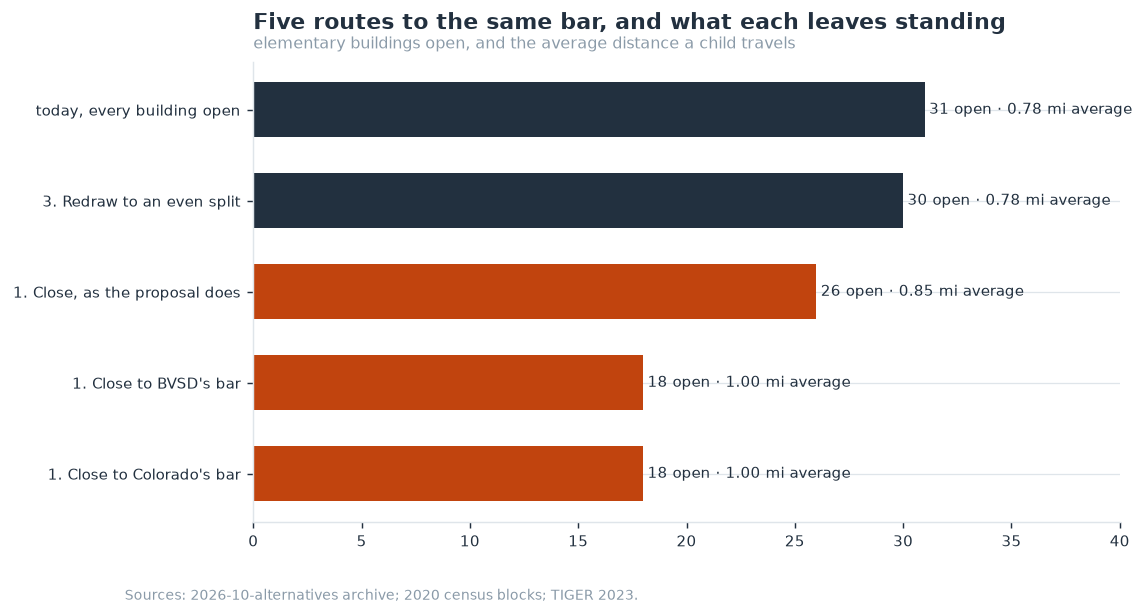

In [21]:
summary_rows = [base, lever1_four, lever1_bvsd, lever1_co, lever3]
levers = pd.DataFrame(summary_rows)
closed_proposal = int(base["schools_open"] - lever1_four["schools_open"])
closed_to_bar = int(base["schools_open"] - lever1_bvsd["schools_open"])
levers["what it gives up"] = [
    "nothing; sixteen schools stay below the bar",
    f"{closed_proposal} buildings, and about {lever1_four['mean_miles_to_school'] - base['mean_miles_to_school']:.2f} "
    f"of a mile on the average journey; eight schools stay below the bar",
    f"{closed_to_bar} buildings - what it takes to clear the district's own bar by closing alone",
    f"{closed_to_bar} buildings - the same, on Colorado's observed bar",
    f"no buildings; {moved / current.sum():.0%} of elementary pupils change school",
]
print(levers.round(2).to_string(index=False))
levers.to_csv(OUTPUT / "alt-levers-summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
order = levers.sort_values("schools_open")
y = np.arange(len(order))
ax.barh(y, order["schools_open"], color=[ACCENT if "Close" in l else INK
                                         for l in order["lever"]], height=0.6)
ax.set_yticks(y, order["lever"])
for i, (n, m) in enumerate(zip(order["schools_open"], order["mean_miles_to_school"])):
    ax.text(n + 0.2, i, f"{n} open · {m:.2f} mi average", va="center", fontsize=8.5, color=INK)
ax.set_xlim(0, 40)
finish(ax, "Five routes to the same bar, and what each leaves standing",
       "elementary buildings open, and the average distance a child travels",
       "Sources: 2026-10-alternatives archive; 2020 census blocks; TIGER 2023.")
fig.savefig(OUTPUT / "alt-fig5-levers.png", bbox_inches="tight")
plt.show()

## What this does not settle

- **Capacity exists for two schools.** The work session gives capacity and
  utilisation for Mesa and Bear Creek only; every other school's is in the
  deck as a chart rather than a table. So utilisation — the district's
  second metric, and the one the 68%-to-75% target is stated in — cannot be
  computed here for 29 of the 31 elementary schools. Every bar above is in
  pupils and pupils a grade instead. **A table of capacity by school would
  close this, and it is the single most useful thing still missing.**
- **The catchment model matches one of its two checks.** Mesa within 6%,
  Bear Creek at 45%. It is used only for comparisons between levers, which
  share the bias, and never for a claim about one school.
- **Catchments here are straight-line nearest-school.** The district says
  67-70% of its students attend their neighbourhood school, so roughly a
  third of the real assignment is choice this model does not see. BVSD's own
  Enrollment Pattern Matrices, already in `2026-09-bvsd/data/raw/`, would
  close that gap.
- **The 2020 census is the child geography.** Five years of building in
  Erie, Superior and north Boulder are not in it, and the district's own
  projections use parcel records and birth certificates this notebook has no
  access to.
- **Focus schools are not catchment schools.** High Peaks, Community
  Montessori and BCSIS draw district-wide, so the nearest-school model
  describes them badly. The proposal moves all three.
- **Nothing here is costed**, by instruction. The proposal's own figures put
  facility modifications at $7.5m to $10m and avoided capital at about
  $44.8m; none of that is weighed above, and it would change the ranking of
  levers if it were.
- **The closure labels behind section 1 are auto-generated** and, outside
  Boulder, never hand-verified.

## The one-line version

The demography is real: Boulder County's school-age population has fallen
and will fall a little further before flattening. **What is not established
is that closing buildings is the only response to it, or that four is the
number.** By the district's own standard 14 schools are already too small;
by this model 16 are. The proposal's closures leave eight. Clearing the bar
by closure alone would take thirteen. Redrawing boundaries across the
buildings that already exist clears it without closing any — and that option
is not on the list the board was given.